# Soft-target next-token prediction on WikiText-2

This notebook compares standard hard-target language-model training with two soft alternatives: ordinary label smoothing and a similarity-based soft target. The main question is whether a representation-aware training target improves data efficiency, and whether any gain survives once runtime cost is taken into account.


In [ ]:
# ============================================================
# 0. Install
# ============================================================
!pip -q install transformers datasets accelerate tqdm

# ============================================================
# 1. Imports and config
# ============================================================
import math
import random
import numpy as np
from dataclasses import dataclass

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, GPT2LMHeadModel, GPT2Config
from tqdm.auto import tqdm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

@dataclass
class CFG:
    dataset_name: str = "wikitext"
    dataset_config: str = "wikitext-2-raw-v1"

    tokenizer_name: str = "openai-community/gpt2"
    external_embedding_model: str = "openai-community/gpt2"

    block_size: int = 128
    batch_size: int = 4
    eval_batch_size: int = 4

    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 256

    lr: float = 3e-4
    weight_decay: float = 0.01
    epochs: int = 1
    max_train_steps: int = 1000
    eval_every: int = 200

    tau: float = 0.07
    label_smoothing_epsilon: float = 0.05
    soft_loss_chunk_size: int = 128

    # Set to hard for baseline, soft for the project objective.
    train_objective: str = "soft"

cfg = CFG()

device: cuda


In [ ]:
# ============================================================
# 2. Load WikiText-2 and tokenizer
# ============================================================
raw = load_dataset(cfg.dataset_name, cfg.dataset_config)
print(raw)

tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name)
tokenizer.pad_token = tokenizer.eos_token

def tokenize_fn(batch):
    return tokenizer(batch["text"])

tokenized = raw.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing"
)

def group_texts(examples):
    concatenated = []
    for ids in examples["input_ids"]:
        if len(ids) > 0:
            concatenated.extend(ids + [tokenizer.eos_token_id])

    total_length = (len(concatenated) // cfg.block_size) * cfg.block_size
    concatenated = concatenated[:total_length]

    input_ids = [
        concatenated[i : i + cfg.block_size]
        for i in range(0, total_length, cfg.block_size)
    ]

    return {
        "input_ids": input_ids,
        "attention_mask": [[1] * cfg.block_size for _ in input_ids],
    }

lm_datasets = tokenized.map(
    group_texts,
    batched=True,
    desc=f"Grouping into blocks of {cfg.block_size}"
)

lm_datasets.set_format(type="torch", columns=["input_ids", "attention_mask"])

train_loader = DataLoader(
    lm_datasets["train"],
    batch_size=cfg.batch_size,
    shuffle=True,
)

valid_loader = DataLoader(
    lm_datasets["validation"],
    batch_size=cfg.eval_batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    lm_datasets["test"],
    batch_size=cfg.eval_batch_size,
    shuffle=False,
)

print("train batches:", len(train_loader))
print("valid batches:", len(valid_loader))
print("test batches:", len(test_loader))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

Tokenizing:   0%|          | 0/3760 [00:00<?, ? examples/s]

Grouping into blocks of 128:   0%|          | 0/4358 [00:00<?, ? examples/s]

Grouping into blocks of 128:   0%|          | 0/36718 [00:00<?, ? examples/s]

Grouping into blocks of 128:   0%|          | 0/3760 [00:00<?, ? examples/s]

train batches: 4714
valid batches: 488
test batches: 559


In [ ]:
# ============================================================
# 3. Build a small decoder-only LM from scratch
# ============================================================
model_config = GPT2Config(
    vocab_size=len(tokenizer),
    n_positions=cfg.block_size,
    n_ctx=cfg.block_size,
    n_embd=cfg.n_embd,
    n_layer=cfg.n_layer,
    n_head=cfg.n_head,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

model = GPT2LMHeadModel(model_config).to(device)
print("number of parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

number of parameters: 16.058112 M


In [ ]:
# ============================================================
# 4. Load fixed external GPT-2 token embeddings
# ============================================================
# These embeddings are NOT trained. They define q_soft(v | w_t).
with torch.no_grad():
    external_model = GPT2LMHeadModel.from_pretrained(cfg.external_embedding_model)
    ext_emb = external_model.transformer.wte.weight.detach().clone()

del external_model

ext_emb = ext_emb.to(device)
ext_emb = F.normalize(ext_emb, p=2, dim=-1)
# consine similarity = target_emb @ ext_emb.T

print("external embedding matrix:", ext_emb.shape)
print("vocab size:", len(tokenizer))

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

external embedding matrix: torch.Size([50257, 768])
vocab size: 50257


In [ ]:
# ============================================================
# 5. Loss functions
# ============================================================
def hard_next_token_loss(logits, input_ids):
    """
    Standard next-token prediction:
    target is one-hot, implemented as class indices.
    """
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()

    #next-token cross entropy/one-hot target
    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1)
    )
    return loss

#soft-target next token loss
def label_smoothing_next_token_loss(logits, input_ids, epsilon=0.05):
    """
    Non-representational soft-target baseline.
    The observed token keeps most probability mass; the remaining mass is
    spread uniformly across the vocabulary by PyTorch's label_smoothing option.
    """
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()

    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        label_smoothing=epsilon,
    )
    return loss


def soft_target_next_token_loss(
    logits,
    input_ids,
    ext_emb,
    tau=0.07,
    chunk_size=128,
):
    """
    Soft-target next-token prediction:

        q_soft(v | w_t) proportional to exp(cos(e_wt, e_v) / tau)

        loss = - sum_v q_soft(v | w_t) log p_model(v | context)

    ext_emb must be L2-normalized, so dot product is cosine similarity.
    """
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()

    vocab_size = shift_logits.size(-1)

    logits_flat = shift_logits.view(-1, vocab_size)
    labels_flat = shift_labels.view(-1)

    total_loss = torch.zeros([], device=logits.device)
    total_count = 0

    for start in range(0, logits_flat.size(0), chunk_size):
        end = min(start + chunk_size, logits_flat.size(0))

        logits_chunk = logits_flat[start:end]
        labels_chunk = labels_flat[start:end]

        log_probs = F.log_softmax(logits_chunk, dim=-1)

        with torch.no_grad():
            target_emb = ext_emb[labels_chunk]
            sims = target_emb @ ext_emb.T
            q_soft = F.softmax(sims / tau, dim=-1)
            #next token embedding, calculate cosine similarity with vocab tokens, softmax+temperature.

        #soft loss
        loss_chunk = -(q_soft * log_probs).sum(dim=-1)
        total_loss = total_loss + loss_chunk.sum()
        total_count += loss_chunk.numel()

    return total_loss / total_count

In [ ]:
# ============================================================
# 6. Evaluation metrics
# ============================================================
@torch.no_grad()
def compute_ece(confidences, correct, n_bins=10):
    confidences = torch.cat(confidences)
    correct = torch.cat(correct).float()

    ece = torch.zeros([], device=confidences.device)

    for i in range(n_bins):
        lo = i / n_bins
        hi = (i + 1) / n_bins

        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            bin_conf = confidences[mask].mean()
            bin_acc = correct[mask].mean()
            ece += mask.float().mean() * (bin_conf - bin_acc).abs()

    return ece.item()

#hard_ce, ppl, top1 acc, top5 acc, top1 emb distance, expected emb distance, average iv, ece
@torch.no_grad()
def evaluate(model, loader, ext_emb, max_batches=None, iv_chunk_size=128):
    """
    Evaluate a model on a loader.

    max_batches=None means evaluate the full split. During training curves we use
    a smaller max_batches value to keep checkpoint evaluation affordable; final
    validation/test evaluation uses the full split by default.
    """
    model.eval()

    total_nll = 0.0
    total_tokens = 0

    total_correct = 0
    total_top5 = 0

    top1_emb_dist_sum = 0.0
    expected_emb_dist_sum = 0.0
    average_iv_sum = 0.0

    confidences = []
    correctness = []

    for step, batch in enumerate(loader):
        if max_batches is not None and step >= max_batches:
            break

        input_ids = batch["input_ids"].to(device)
        outputs = model(input_ids=input_ids)
        logits = outputs.logits

        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = input_ids[:, 1:].contiguous()

        vocab_size = shift_logits.size(-1)
        logits_flat = shift_logits.view(-1, vocab_size)
        labels_flat = shift_labels.view(-1)

        # standard hard-target CE
        ce_sum = F.cross_entropy(logits_flat, labels_flat, reduction="sum")
        total_nll += ce_sum.item()
        total_tokens += labels_flat.numel()

        # top-1 accuracy+top-5 accuracy
        probs = F.softmax(logits_flat, dim=-1)
        conf, pred = probs.max(dim=-1)

        correct = pred.eq(labels_flat)
        total_correct += correct.sum().item()

        top5 = logits_flat.topk(5, dim=-1).indices
        total_top5 += top5.eq(labels_flat.unsqueeze(-1)).any(dim=-1).sum().item()

        confidences.append(conf.detach())
        correctness.append(correct.detach())

        # top-1 embedding distance
        target_emb = ext_emb[labels_flat]
        pred_emb = ext_emb[pred]

        # disntance between top-1 predicted token and target token
        top1_dist = 1.0 - (pred_emb * target_emb).sum(dim=-1)
        top1_emb_dist_sum += top1_dist.sum().item()

        # expected embedding distance
        expected_emb = probs @ ext_emb
        expected_emb = F.normalize(expected_emb, p=2, dim=-1)
        expected_dist = 1.0 - (expected_emb * target_emb).sum(dim=-1)
        expected_emb_dist_sum += expected_dist.sum().item()

        for start in range(0, logits_flat.size(0), iv_chunk_size):
            end = min(start + iv_chunk_size, logits_flat.size(0))

            probs_chunk = probs[start:end]
            target_emb_chunk = target_emb[start:end]

            #IV-like metric/expected embedding distance
            sims = target_emb_chunk @ ext_emb.T
            distances = 1.0 - sims

            average_iv = (probs_chunk * distances).sum(dim=-1)
            average_iv_sum += average_iv.sum().item()

    avg_ce = total_nll / total_tokens
    ppl = math.exp(min(avg_ce, 20))

    metrics = {
        "hard_ce": avg_ce,
        "perplexity": ppl,
        "accuracy": total_correct / total_tokens,
        "top5_accuracy": total_top5 / total_tokens,
        "top1_embedding_distance": top1_emb_dist_sum / total_tokens,
        "expected_embedding_distance": expected_emb_dist_sum / total_tokens,
        "average_iv": average_iv_sum / total_tokens,
        "ece": compute_ece(confidences, correctness),
    }

    model.train()
    return metrics


In [ ]:
# ============================================================
# 7. Experiment runner
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import time

sns.set_theme(style="whitegrid")

# One full pass over the grouped WikiText-2 train split.
FULL_EPOCH_STEPS = len(train_loader)
FULL_MAX_TRAIN_STEPS = FULL_EPOCH_STEPS
FULL_EVAL_EVERY = 500
CURVE_EVAL_MAX_BATCHES = 50
FINAL_EVAL_MAX_BATCHES = None  # None = full validation/test split for final metrics.

print("Full WikiText-2 train steps:", FULL_EPOCH_STEPS)
print("Approx target tokens per epoch:", FULL_EPOCH_STEPS * cfg.batch_size * (cfg.block_size - 1))


def make_model():
    model_config = GPT2Config(
        vocab_size=len(tokenizer),
        n_positions=cfg.block_size,
        n_ctx=cfg.block_size,
        n_embd=cfg.n_embd,
        n_layer=cfg.n_layer,
        n_head=cfg.n_head,
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return GPT2LMHeadModel(model_config).to(device)


def reset_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def run_experiment(
    run_name,
    objective,
    tau=None,
    label_smoothing_epsilon=0.05,
    max_train_steps=FULL_MAX_TRAIN_STEPS,
    eval_every=FULL_EVAL_EVERY,
    run_seed=42,
    eval_max_batches=CURVE_EVAL_MAX_BATCHES,
    final_eval_max_batches=FINAL_EVAL_MAX_BATCHES,
):
    print(f"\n===== Running {run_name} =====")

    reset_seed(run_seed)

    model = make_model()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    history = []
    global_step = 0
    model.train()

    start_time = time.perf_counter()
    tokens_seen = 0

    progress = tqdm(total=max_train_steps, desc=run_name)

    while global_step < max_train_steps:
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)

            outputs = model(input_ids=input_ids)
            logits = outputs.logits

            if objective == "hard":
                loss = hard_next_token_loss(logits, input_ids)
            elif objective == "label_smoothing":
                loss = label_smoothing_next_token_loss(
                    logits,
                    input_ids,
                    epsilon=label_smoothing_epsilon,
                )
            elif objective == "soft":
                loss = soft_target_next_token_loss(
                    logits,
                    input_ids,
                    ext_emb=ext_emb,
                    tau=tau,
                    chunk_size=cfg.soft_loss_chunk_size,
                )
            else:
                raise ValueError("objective must be 'hard', 'label_smoothing', or 'soft'")

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            global_step += 1
            tokens_seen += input_ids[:, 1:].numel()
            elapsed_sec = time.perf_counter() - start_time

            progress.update(1)
            progress.set_postfix({"loss": round(loss.item(), 4)})

            if global_step % eval_every == 0 or global_step == max_train_steps:
                metrics = evaluate(
                    model,
                    valid_loader,
                    ext_emb,
                    max_batches=eval_max_batches,
                )
                row = {
                    "run": run_name,
                    "objective": objective,
                    "tau": tau if tau is not None else "none",
                    "label_smoothing_epsilon": (
                        label_smoothing_epsilon if objective == "label_smoothing" else "none"
                    ),
                    "step": global_step,
                    "tokens_seen": tokens_seen,
                    "elapsed_sec": elapsed_sec,
                    **metrics,
                }
                history.append(row)

                print(f"\nEval {run_name} step {global_step}")
                print(f"perplexity: {metrics['perplexity']:.4f}")
                print(f"accuracy: {metrics['accuracy']:.4f}")
                print(f"top5_accuracy: {metrics['top5_accuracy']:.4f}")
                print(f"expected_embedding_distance: {metrics['expected_embedding_distance']:.4f}")
                print(f"ece: {metrics['ece']:.4f}")

            if global_step >= max_train_steps:
                break

    progress.close()

    final_valid_metrics = evaluate(
        model,
        valid_loader,
        ext_emb,
        max_batches=final_eval_max_batches,
    )
    final_test_metrics = evaluate(
        model,
        test_loader,
        ext_emb,
        max_batches=final_eval_max_batches,
    )

    final = {
        "run": run_name,
        "objective": objective,
        "tau": tau if tau is not None else "none",
        "label_smoothing_epsilon": (
            label_smoothing_epsilon if objective == "label_smoothing" else "none"
        ),
        "step": global_step,
        "tokens_seen": tokens_seen,
        "elapsed_sec": time.perf_counter() - start_time,
        **final_valid_metrics,
    }
    for k, v in final_test_metrics.items():
        final[f"test_{k}"] = v

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return history, final


Full WikiText-2 train steps: 4714
Approx target tokens per epoch: 2394712


,tau,entropy,top1_mass,top10_mass,top100_mass
0,0.03,0.017201,0.997200,0.999942,0.999998
1,0.05,0.345412,0.960221,0.983644,0.987929
2,0.07,4.953574,0.555738,0.602988,0.630411
3,0.10,10.158621,0.058221,0.076127,0.101855
4,0.20,10.787958,0.001141,0.002803,0.009460


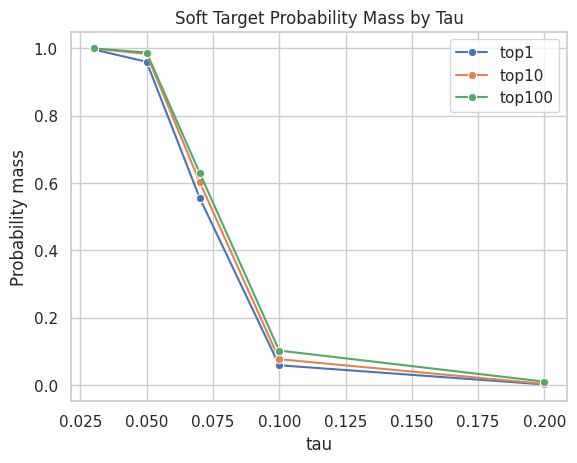

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def inspect_soft_targets(ext_emb, labels, taus=[0.03, 0.05, 0.07, 0.10, 0.20]):
    rows = []
    labels = labels.to(ext_emb.device)

    for tau in taus:
        target_emb = ext_emb[labels]
        sims = target_emb @ ext_emb.T
        q = F.softmax(sims / tau, dim=-1)

        entropy = -(q * torch.log(q + 1e-12)).sum(dim=-1)
        top1_mass = q.max(dim=-1).values
        top10_mass = q.topk(10, dim=-1).values.sum(dim=-1)
        top100_mass = q.topk(100, dim=-1).values.sum(dim=-1)

        rows.append({
            "tau": tau,
            "entropy": entropy.mean().item(),
            "top1_mass": top1_mass.mean().item(),
            "top10_mass": top10_mass.mean().item(),
            "top100_mass": top100_mass.mean().item(),
        })

    return pd.DataFrame(rows)

batch = next(iter(train_loader))
sample_labels = batch["input_ids"][:, 1:].reshape(-1)[:256].to(device)

soft_stats = inspect_soft_targets(
    ext_emb,
    sample_labels,
    taus=[0.03, 0.05, 0.07, 0.10, 0.20],
)

display(soft_stats)

sns.lineplot(data=soft_stats, x="tau", y="top1_mass", marker="o", label="top1")
sns.lineplot(data=soft_stats, x="tau", y="top10_mass", marker="o", label="top10")
sns.lineplot(data=soft_stats, x="tau", y="top100_mass", marker="o", label="top100")
plt.title("Soft Target Probability Mass by Tau")
plt.ylabel("Probability mass")
plt.show()

In [ ]:
# ============================================================
# 8. Run full WikiText-2 one-epoch sweep
# ============================================================
experiments = [
    {"run_name": "hard_baseline", "objective": "hard", "tau": None},
    {"run_name": "label_smoothing_0.05", "objective": "label_smoothing", "tau": None, "epsilon": 0.05},
    {"run_name": "soft_tau_0.05", "objective": "soft", "tau": 0.05},
    {"run_name": "soft_tau_0.06", "objective": "soft", "tau": 0.06},
]

# For a quick smoke test, use seeds = [42].
# For the final project run, use all three seeds.
seeds = [42, 43, 44]

all_history = []
final_results = []

for s in seeds:
    for exp in experiments:
        run_name = f'{exp["run_name"]}_seed{s}'

        hist, final = run_experiment(
            run_name=run_name,
            objective=exp["objective"],
            tau=exp["tau"],
            label_smoothing_epsilon=exp.get("epsilon", cfg.label_smoothing_epsilon),
            max_train_steps=FULL_MAX_TRAIN_STEPS,
            eval_every=FULL_EVAL_EVERY,
            run_seed=s,
            eval_max_batches=CURVE_EVAL_MAX_BATCHES,
            final_eval_max_batches=FINAL_EVAL_MAX_BATCHES,
        )

        for row in hist:
            row["seed"] = s
            row["base_run"] = exp["run_name"]

        final["seed"] = s
        final["base_run"] = exp["run_name"]

        all_history.extend(hist)
        final_results.append(final)

history_df = pd.DataFrame(all_history)
final_df = pd.DataFrame(final_results)

display(final_df)



===== Running hard_baseline_seed42 =====


hard_baseline_seed42:   0%|          | 0/4714 [00:00<?, ?it/s]


Eval hard_baseline_seed42 step 500
perplexity: 730.0442
accuracy: 0.1804
top5_accuracy: 0.3244
expected_embedding_distance: 0.4308
ece: 0.0332

Eval hard_baseline_seed42 step 1000
perplexity: 546.4741
accuracy: 0.1971
top5_accuracy: 0.3415
expected_embedding_distance: 0.4167
ece: 0.0120

Eval hard_baseline_seed42 step 1500
perplexity: 465.9097
accuracy: 0.2017
top5_accuracy: 0.3510
expected_embedding_distance: 0.4122
ece: 0.0214

Eval hard_baseline_seed42 step 2000
perplexity: 417.2737
accuracy: 0.2144
top5_accuracy: 0.3615
expected_embedding_distance: 0.4085
ece: 0.0175

Eval hard_baseline_seed42 step 2500
perplexity: 377.0829
accuracy: 0.2161
top5_accuracy: 0.3681
expected_embedding_distance: 0.4060
ece: 0.0217

Eval hard_baseline_seed42 step 3000
perplexity: 343.8713
accuracy: 0.2206
top5_accuracy: 0.3741
expected_embedding_distance: 0.4029
ece: 0.0205

Eval hard_baseline_seed42 step 3500
perplexity: 321.9923
accuracy: 0.2274
top5_accuracy: 0.3775
expected_embedding_distance: 0.399

label_smoothing_0.05_seed42:   0%|          | 0/4714 [00:00<?, ?it/s]


Eval label_smoothing_0.05_seed42 step 500
perplexity: 722.1633
accuracy: 0.1809
top5_accuracy: 0.3253
expected_embedding_distance: 0.4316
ece: 0.0351

Eval label_smoothing_0.05_seed42 step 1000
perplexity: 534.2090
accuracy: 0.1970
top5_accuracy: 0.3417
expected_embedding_distance: 0.4168
ece: 0.0133

Eval label_smoothing_0.05_seed42 step 1500
perplexity: 455.0138
accuracy: 0.2026
top5_accuracy: 0.3524
expected_embedding_distance: 0.4119
ece: 0.0190

Eval label_smoothing_0.05_seed42 step 2000
perplexity: 410.2427
accuracy: 0.2165
top5_accuracy: 0.3624
expected_embedding_distance: 0.4084
ece: 0.0214

Eval label_smoothing_0.05_seed42 step 2500
perplexity: 371.0834
accuracy: 0.2157
top5_accuracy: 0.3683
expected_embedding_distance: 0.4060
ece: 0.0166

Eval label_smoothing_0.05_seed42 step 3000
perplexity: 337.1946
accuracy: 0.2237
top5_accuracy: 0.3759
expected_embedding_distance: 0.4023
ece: 0.0178

Eval label_smoothing_0.05_seed42 step 3500
perplexity: 318.6693
accuracy: 0.2272
top5_ac

...

soft_tau_0.05_seed44:   0%|          | 0/4714 [00:00<?, ?it/s]


Eval soft_tau_0.05_seed44 step 500
perplexity: 716.0481
accuracy: 0.1810
top5_accuracy: 0.3244
expected_embedding_distance: 0.4281
ece: 0.0300

Eval soft_tau_0.05_seed44 step 1000
perplexity: 520.6810
accuracy: 0.2017
top5_accuracy: 0.3422
expected_embedding_distance: 0.4160
ece: 0.0263

Eval soft_tau_0.05_seed44 step 1500
perplexity: 450.6023
accuracy: 0.2066
top5_accuracy: 0.3532
expected_embedding_distance: 0.4111
ece: 0.0209

Eval soft_tau_0.05_seed44 step 2000
perplexity: 392.6563
accuracy: 0.2176
top5_accuracy: 0.3619
expected_embedding_distance: 0.4064
ece: 0.0191

Eval soft_tau_0.05_seed44 step 2500
perplexity: 361.1768
accuracy: 0.2216
top5_accuracy: 0.3677
expected_embedding_distance: 0.4036
ece: 0.0167

Eval soft_tau_0.05_seed44 step 3000
perplexity: 331.4686
accuracy: 0.2252
top5_accuracy: 0.3761
expected_embedding_distance: 0.4007
ece: 0.0139

Eval soft_tau_0.05_seed44 step 3500
perplexity: 311.2856
accuracy: 0.2306
top5_accuracy: 0.3798
expected_embedding_distance: 0.398

soft_tau_0.06_seed44:   0%|          | 0/4714 [00:00<?, ?it/s]


Eval soft_tau_0.06_seed44 step 500
perplexity: 702.2355
accuracy: 0.1814
top5_accuracy: 0.3269
expected_embedding_distance: 0.4281
ece: 0.0379

Eval soft_tau_0.06_seed44 step 1000
perplexity: 517.6621
accuracy: 0.2044
top5_accuracy: 0.3435
expected_embedding_distance: 0.4165
ece: 0.0321

Eval soft_tau_0.06_seed44 step 1500
perplexity: 452.7463
accuracy: 0.2066
top5_accuracy: 0.3550
expected_embedding_distance: 0.4118
ece: 0.0278

Eval soft_tau_0.06_seed44 step 2000
perplexity: 398.0567
accuracy: 0.2190
top5_accuracy: 0.3636
expected_embedding_distance: 0.4073
ece: 0.0311

Eval soft_tau_0.06_seed44 step 2500
perplexity: 362.2010
accuracy: 0.2222
top5_accuracy: 0.3670
expected_embedding_distance: 0.4035
ece: 0.0243

Eval soft_tau_0.06_seed44 step 3000
perplexity: 334.8434
accuracy: 0.2239
top5_accuracy: 0.3759
expected_embedding_distance: 0.4012
ece: 0.0172

Eval soft_tau_0.06_seed44 step 3500
perplexity: 317.2416
accuracy: 0.2313
top5_accuracy: 0.3815
expected_embedding_distance: 0.399

,run,objective,tau,label_smoothing_epsilon,step,tokens_seen,elapsed_sec,hard_ce,perplexity,accuracy,...,test_hard_ce,test_perplexity,test_accuracy,test_top5_accuracy,test_top1_embedding_distance,test_expected_embedding_distance,test_average_iv,test_ece,seed,base_run
0,hard_baseline_seed42,hard,none,none,4714,2394458,84.671965,5.670412,290.154079,0.216473,...,5.681295,293.328964,0.214661,0.369723,0.534987,0.399433,0.620284,0.017428,42,hard_baseline
1,label_smoothing_0.05_seed42,label_smoothing,none,0.05,4714,2394458,86.035399,5.658864,286.822709,0.216715,...,5.667775,289.389844,0.214979,0.370410,0.534235,0.399356,0.627701,0.012460,42,label_smoothing_0.05
2,soft_tau_0.05_seed42,soft,0.05,none,4714,2394458,95.563720,5.647275,283.517862,0.216994,...,5.661232,287.502497,0.214809,0.370216,0.535063,0.399112,0.621051,0.014120,42,soft_tau_0.05
3,soft_tau_0.06_seed42,soft,0.06,none,4714,2394458,94.906653,5.676968,292.062645,0.218230,...,5.685866,294.672793,0.216082,0.371211,0.535051,0.399467,0.630648,0.012949,42,soft_tau_0.06
4,hard_baseline_seed43,hard,none,none,4714,2394458,83.398571,5.650508,284.435947,0.218654,...,5.665243,288.658077,0.214372,0.372639,0.535583,0.399151,0.623747,0.009151,43,hard_baseline
5,label_smoothing_0.05_seed43,label_smoothing,none,0.05,4714,2394458,84.275380,5.641505,281.886567,0.219616,...,5.654326,285.523944,0.215370,0.374081,0.534847,0.399083,0.631998,0.011001,43,label_smoothing_0.05
6,soft_tau_0.05_seed43,soft,0.05,none,4714,2394458,95.175836,5.635289,280.139962,0.218319,...,5.648635,283.903804,0.214622,0.373411,0.535993,0.399005,0.624825,0.009619,43,soft_tau_0.05
7,soft_tau_0.06_seed43,soft,0.06,none,4714,2394458,94.961011,5.662909,287.985279,0.219943,...,5.674180,291.249562,0.215751,0.374585,0.535170,0.399349,0.633036,0.015357,43,soft_tau_0.06
8,hard_baseline_seed44,hard,none,none,4714,2394458,82.849000,5.657542,286.443726,0.216529,...,5.666782,289.102767,0.214718,0.372385,0.534335,0.398932,0.619111,0.018381,44,hard_baseline
9,label_smoothing_0.05_seed44,label_smoothing,none,0.05,4714,2394458,84.277782,5.648665,283.912175,0.217059,...,5.656319,286.093729,0.214802,0.372935,0.534449,0.399032,0.627270,0.012471,44,label_smoothing_0.05


## Results and analysis

The results are organised around two axes.

1. **Efficiency axis**: Does a training objective improve performance as a function of training data (`tokens_seen`) or as a function of computational time (`wall-clock time`)?
2. **Evaluation-value axis**: Does the conclusion change when the evaluation value is exact-token prediction (`perplexity`) versus representational closeness (`expected_embedding_distance`)?

The main figure is a 2 x 2 trade-off matrix. Columns compare data efficiency and runtime efficiency; rows compare PPL evaluation and expected-embedding-distance evaluation. Label smoothing is included as a non-representational soft-target baseline, so improvements from the similarity-based soft target cannot be attributed only to softening the labels.


In [ ]:
# ============================================================
# 9. Paper-style plotting setup
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid", context="paper", font_scale=1.25)

METHOD_ORDER = ["hard_baseline", "label_smoothing_0.05", "soft_tau_0.05", "soft_tau_0.06"]
METHOD_LABELS = {
    "hard_baseline": "Hard target",
    "label_smoothing_0.05": "Label smoothing",
    "soft_tau_0.05": "Soft target, tau=0.05",
    "soft_tau_0.06": "Soft target, tau=0.06",
}
METHOD_PALETTE = {
    "Hard target": "#4C72B0",
    "Label smoothing": "#8172B3",
    "Soft target, tau=0.05": "#DD8452",
    "Soft target, tau=0.06": "#55A868",
}

history_plot = history_df.copy()
final_plot = final_df.copy()

history_plot["method"] = pd.Categorical(
    history_plot["base_run"].map(METHOD_LABELS),
    categories=[METHOD_LABELS[m] for m in METHOD_ORDER],
    ordered=True,
)
final_plot["method"] = pd.Categorical(
    final_plot["base_run"].map(METHOD_LABELS),
    categories=[METHOD_LABELS[m] for m in METHOD_ORDER],
    ordered=True,
)

history_plot["tokens_seen_m"] = history_plot["tokens_seen"] / 1_000_000
history_plot["elapsed_sec_plot"] = history_plot["elapsed_sec"]
final_plot["elapsed_sec_plot"] = final_plot["elapsed_sec"]

# Check that the key result columns exist before plotting.
required_cols = ["perplexity", "expected_embedding_distance", "tokens_seen", "elapsed_sec", "seed", "base_run"]
missing = [c for c in required_cols if c not in history_plot.columns]
if missing:
    raise ValueError(f"Missing columns in history_df: {missing}")


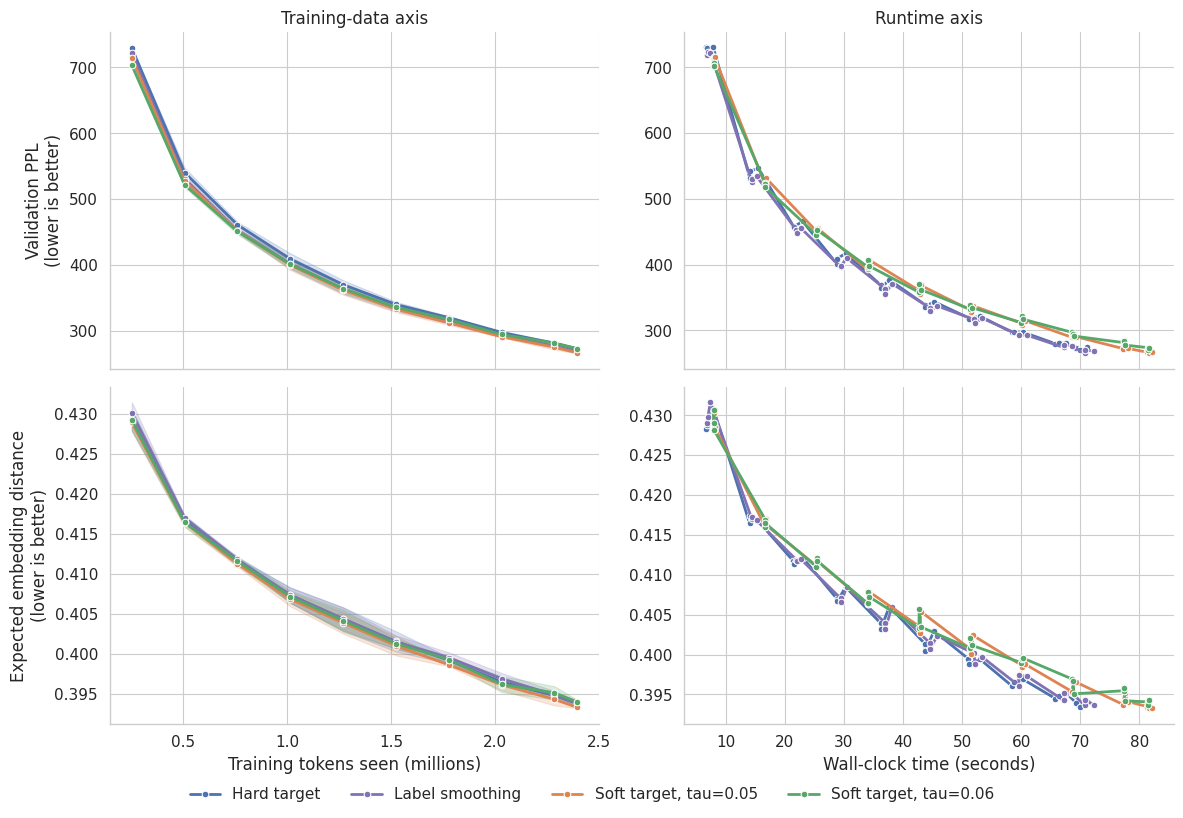

In [ ]:
# ============================================================
# Figure 1. Efficiency trade-off matrix
# ============================================================
# Columns show the efficiency axis. Rows show the evaluation value.

eval_history = history_plot.dropna(
    subset=["perplexity", "expected_embedding_distance"]
).copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex="col")

panels = [
    (axes[0, 0], "tokens_seen_m", "perplexity"),
    (axes[0, 1], "elapsed_sec_plot", "perplexity"),
    (axes[1, 0], "tokens_seen_m", "expected_embedding_distance"),
    (axes[1, 1], "elapsed_sec_plot", "expected_embedding_distance"),
]

for ax, x, y in panels:
    sns.lineplot(
        data=eval_history,
        x=x,
        y=y,
        hue="method",
        hue_order=[METHOD_LABELS[m] for m in METHOD_ORDER],
        palette=METHOD_PALETTE,
        marker="o",
        errorbar="sd",
        linewidth=2,
        ax=ax,
    )

axes[0, 0].set_title("Training-data axis")
axes[0, 1].set_title("Runtime axis")
axes[0, 0].set_ylabel("Validation PPL\n(lower is better)")
axes[1, 0].set_ylabel("Expected embedding distance\n(lower is better)")
axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")
axes[1, 0].set_xlabel("Training tokens seen (millions)")
axes[1, 1].set_xlabel("Wall-clock time (seconds)")
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")

handles, labels = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.03),
)
sns.despine(fig=fig)
plt.tight_layout()

from pathlib import Path
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
fig.savefig(FIG_DIR / "efficiency_tradeoff_matrix.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "efficiency_tradeoff_matrix.png", dpi=300, bbox_inches="tight")

plt.show()


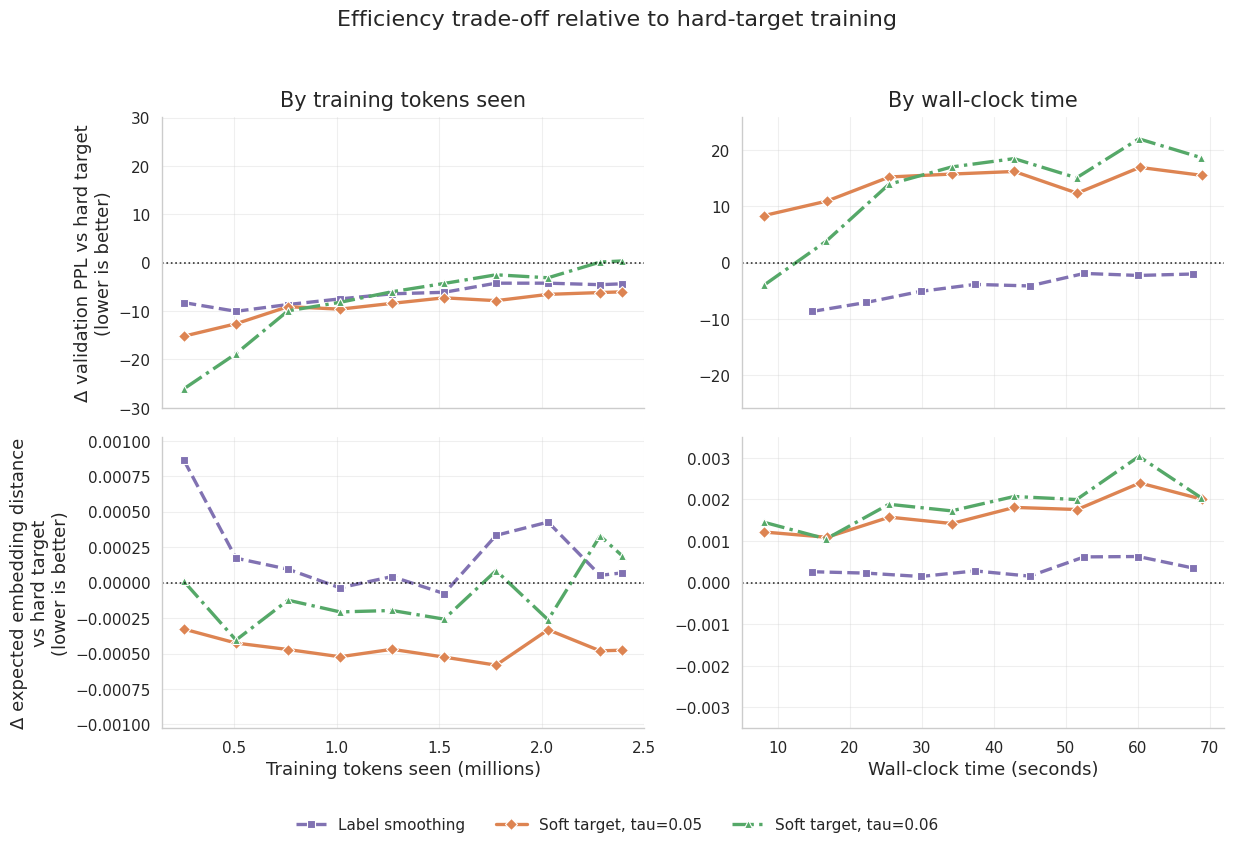

In [ ]:
# detailed?
# ============================================================
# Figure 1. Relative efficiency trade-off matrix
# Difference from hard-target baseline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="paper", font_scale=1.25)

# ------------------------------------------------------------
# 1. Prepare validation history
# ------------------------------------------------------------
eval_history = history_plot.dropna(
    subset=["perplexity", "expected_embedding_distance"]
).copy()

# Make x-axis columns if needed
if "tokens_seen_m" not in eval_history.columns:
    eval_history["tokens_seen_m"] = eval_history["tokens_seen"] / 1_000_000

if "elapsed_sec_plot" not in eval_history.columns:
    eval_history["elapsed_sec_plot"] = eval_history["elapsed_sec"]

method_order = [METHOD_LABELS[m] for m in METHOD_ORDER]

eval_history["method"] = pd.Categorical(
    eval_history["method"],
    categories=method_order,
    ordered=True,
)

# Aggregate over seeds at each method-step
agg = (
    eval_history
    .groupby(["method", "step"], observed=True)
    .agg(
        tokens_seen_m=("tokens_seen_m", "mean"),
        elapsed_sec=("elapsed_sec_plot", "mean"),
        ppl=("perplexity", "mean"),
        ppl_std=("perplexity", "std"),
        eed=("expected_embedding_distance", "mean"),
        eed_std=("expected_embedding_distance", "std"),
    )
    .reset_index()
)

agg[["ppl_std", "eed_std"]] = agg[["ppl_std", "eed_std"]].fillna(0.0)

hard_name = "Hard target"

hard_by_step = (
    agg[agg["method"] == hard_name]
    [["step", "ppl", "eed"]]
    .rename(columns={"ppl": "hard_ppl", "eed": "hard_eed"})
)

# ------------------------------------------------------------
# 2. Training-data axis: compare methods at same step/tokens
# ------------------------------------------------------------
delta_tokens = agg.merge(hard_by_step, on="step", how="left")

delta_tokens["delta_ppl"] = delta_tokens["ppl"] - delta_tokens["hard_ppl"]
delta_tokens["delta_eed"] = delta_tokens["eed"] - delta_tokens["hard_eed"]
delta_tokens["axis_type"] = "tokens"

# Remove hard target from relative curves; it is always zero
delta_tokens = delta_tokens[delta_tokens["method"] != hard_name].copy()


# ------------------------------------------------------------
# 3. Runtime axis: compare methods to hard target at same time
#    using interpolation of the hard-target curve
# ------------------------------------------------------------
hard_curve = agg[agg["method"] == hard_name].sort_values("elapsed_sec")

hard_time = hard_curve["elapsed_sec"].to_numpy()
hard_ppl = hard_curve["ppl"].to_numpy()
hard_eed = hard_curve["eed"].to_numpy()

runtime_rows = []

for method in method_order:
    if method == hard_name:
        continue

    d = agg[agg["method"] == method].sort_values("elapsed_sec").copy()

    # Only compare within the hard-target time range
    d = d[
        (d["elapsed_sec"] >= hard_time.min()) &
        (d["elapsed_sec"] <= hard_time.max())
    ].copy()

    if len(d) == 0:
        continue

    interp_hard_ppl = np.interp(d["elapsed_sec"], hard_time, hard_ppl)
    interp_hard_eed = np.interp(d["elapsed_sec"], hard_time, hard_eed)

    d["hard_ppl_runtime"] = interp_hard_ppl
    d["hard_eed_runtime"] = interp_hard_eed

    d["delta_ppl"] = d["ppl"] - d["hard_ppl_runtime"]
    d["delta_eed"] = d["eed"] - d["hard_eed_runtime"]
    d["axis_type"] = "runtime"

    runtime_rows.append(d)

delta_runtime = pd.concat(runtime_rows, ignore_index=True)


# ------------------------------------------------------------
# 4. Plot settings
# ------------------------------------------------------------
colors = {
    "Label smoothing": "#8172B2",
    "Soft target, tau=0.05": "#DD8452",
    "Soft target, tau=0.06": "#55A868",
}

linestyles = {
    "Label smoothing": "--",
    "Soft target, tau=0.05": "-",
    "Soft target, tau=0.06": "-.",
}

markers = {
    "Label smoothing": "s",
    "Soft target, tau=0.05": "D",
    "Soft target, tau=0.06": "^",
}

plot_methods = [
    "Label smoothing",
    "Soft target, tau=0.05",
    "Soft target, tau=0.06",
]


def draw_relative_panel(ax, data, x_col, y_col, xlabel=None, ylabel=None, title=None):
    for method in plot_methods:
        d = data[data["method"] == method].sort_values(x_col)
        if len(d) == 0:
            continue

        ax.plot(
            d[x_col],
            d[y_col],
            label=method,
            color=colors[method],
            linestyle=linestyles[method],
            marker=markers[method],
            linewidth=2.4,
            markersize=6,
            markeredgecolor="white",
            markeredgewidth=0.8,
        )

    # hard-target reference line
    ax.axhline(
        0,
        color="black",
        linewidth=1.2,
        linestyle=":",
        alpha=0.8,
    )

    if title:
        ax.set_title(title, fontsize=15, pad=8)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=13)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13)

    ax.grid(True, alpha=0.30)
    ax.tick_params(labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# 5. Draw figure
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2), sharex="col")

draw_relative_panel(
    axes[0, 0],
    delta_tokens,
    x_col="tokens_seen_m",
    y_col="delta_ppl",
    title="By training tokens seen",
    ylabel="Δ validation PPL vs hard target\n(lower is better)",
)

draw_relative_panel(
    axes[0, 1],
    delta_runtime,
    x_col="elapsed_sec",
    y_col="delta_ppl",
    title="By wall-clock time",
)

draw_relative_panel(
    axes[1, 0],
    delta_tokens,
    x_col="tokens_seen_m",
    y_col="delta_eed",
    xlabel="Training tokens seen (millions)",
    ylabel="Δ expected embedding distance\nvs hard target\n(lower is better)",
)

draw_relative_panel(
    axes[1, 1],
    delta_runtime,
    x_col="elapsed_sec",
    y_col="delta_eed",
    xlabel="Wall-clock time (seconds)",
)

# Set symmetric-ish y-limits around zero for easier reading
for ax in axes[0, :]:
    ymin, ymax = ax.get_ylim()
    pad = max(abs(ymin), abs(ymax)) * 1.10
    ax.set_ylim(-pad, pad)

for ax in axes[1, :]:
    ymin, ymax = ax.get_ylim()
    pad = max(abs(ymin), abs(ymax)) * 1.10
    ax.set_ylim(-pad, pad)

# Global legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=11,
)

fig.suptitle(
    "Efficiency trade-off relative to hard-target training",
    fontsize=16,
    y=1.01,
)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

fig.savefig(FIG_DIR / "efficiency_tradeoff_relative.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "efficiency_tradeoff_relative.png", dpi=300, bbox_inches="tight")

plt.show()

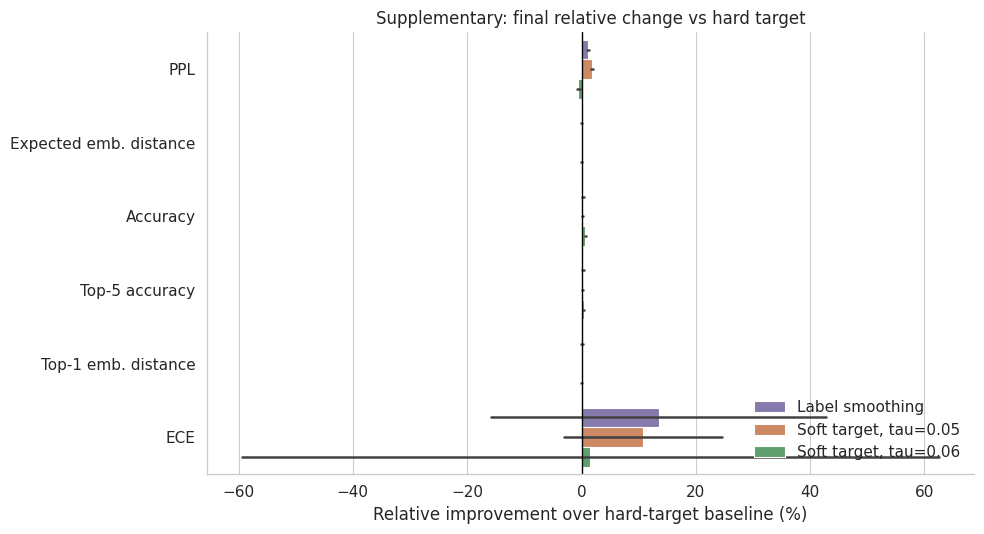

In [ ]:
# ============================================================
# Supplementary figure. Final relative changes against hard target
# ============================================================
# Positive values mean improvement over the hard-target baseline on the held-out test split.
metrics = {
    "test_perplexity": "PPL",
    "test_expected_embedding_distance": "Expected emb. distance",
    "test_accuracy": "Accuracy",
    "test_top5_accuracy": "Top-5 accuracy",
    "test_top1_embedding_distance": "Top-1 emb. distance",
    "test_ece": "ECE",
}
lower_is_better = {
    "test_perplexity": True,
    "test_expected_embedding_distance": True,
    "test_accuracy": False,
    "test_top5_accuracy": False,
    "test_top1_embedding_distance": True,
    "test_ece": True,
}

rows = []
for seed, group in final_df.groupby("seed"):
    baseline = group[group["base_run"] == "hard_baseline"].iloc[0]
    for _, row in group[group["base_run"] != "hard_baseline"].iterrows():
        for metric, label in metrics.items():
            base_value = baseline[metric]
            model_value = row[metric]
            if lower_is_better[metric]:
                improvement = 100 * (base_value - model_value) / base_value
            else:
                improvement = 100 * (model_value - base_value) / base_value
            rows.append({
                "seed": seed,
                "base_run": row["base_run"],
                "method": METHOD_LABELS[row["base_run"]],
                "metric": label,
                "relative_improvement_pct": improvement,
            })

relative_df = pd.DataFrame(rows)
metric_order = ["PPL", "Expected emb. distance", "Accuracy", "Top-5 accuracy", "Top-1 emb. distance", "ECE"]

plt.figure(figsize=(10, 5.5))
sns.barplot(
    data=relative_df,
    x="relative_improvement_pct",
    y="metric",
    hue="method",
    order=metric_order,
    palette=METHOD_PALETTE,
    errorbar="sd",
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Relative improvement over hard-target baseline (%)")
plt.ylabel("")
plt.title("Supplementary: final relative change vs hard target")
plt.legend(title="", frameon=False, loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Table 1. Final held-out test summary
# ============================================================
test_summary_metrics = [
    "test_perplexity",
    "test_expected_embedding_distance",
    "test_accuracy",
    "test_top5_accuracy",
    "test_ece",
]

summary_df = final_df.groupby("base_run")[test_summary_metrics].agg(["mean", "std"])
summary_df = summary_df.rename(index=METHOD_LABELS)
display(summary_df)


test_perplexity            \
                                 mean       std   
base_run                                          
Hard target                290.363269  2.577973   
Label smoothing            287.002506  2.087032   
Soft target, tau=0.05      285.118164  2.065012   
Soft target, tau=0.06      291.978755  2.413522   

                      test_expected_embedding_distance            \
                                                  mean       std   
base_run                                                           
Hard target                                   0.399172  0.000251   
Label smoothing                               0.399157  0.000174   
Soft target, tau=0.05                         0.398903  0.000275   
Soft target, tau=0.06                         0.399152  0.000447   

                      test_accuracy           test_top5_accuracy            \
                               mean       std               mean       std   
base_run                                                                     
Hard target                0.214584  0.000185           0.371582  0.001615   
Label smoothing            0.215050  0.000291           0.372475  0.001878   
Soft target, tau=0.05      0.214880  0.000299           0.371992  0.001627   
Soft target, tau=0.06      0.216028  0.000255           0.373159  0.001747   

                       test_ece            
                           mean       std  
base_run                                   
Hard target            0.014987  0.005076  
Label smoothing        0.011977  0.000845  
Soft target, tau=0.05  0.012912  0.002885  
Soft target, tau=0.06  0.012695  0.002798

tokens_seen      elapsed_sec           test_perplexity  \
                             mean  std        mean       std            mean   
base_run                                                                       
Hard target             2394458.0  0.0   83.639846  0.935126      290.363269   
Label smoothing         2394458.0  0.0   84.862853  1.015455      287.002506   
Soft target, tau=0.05   2394458.0  0.0   95.209885  0.338099      285.118164   
Soft target, tau=0.06   2394458.0  0.0   95.018265  0.148747      291.978755   

                                test_expected_embedding_distance            \
                            std                             mean       std   
base_run                                                                     
Hard target            2.577973                         0.399172  0.000251   
Label smoothing        2.087032                         0.399157  0.000174   
Soft target, tau=0.05  2.065012                         0.398903  0.000275   
Soft target, tau=0.06  2.413522                         0.399152  0.000447   

                      test_accuracy            
                               mean       std  
base_run                                       
Hard target                0.214584  0.000185  
Label smoothing            0.215050  0.000291  
Soft target, tau=0.05      0.214880  0.000299  
Soft target, tau=0.06      0.216028  0.000255

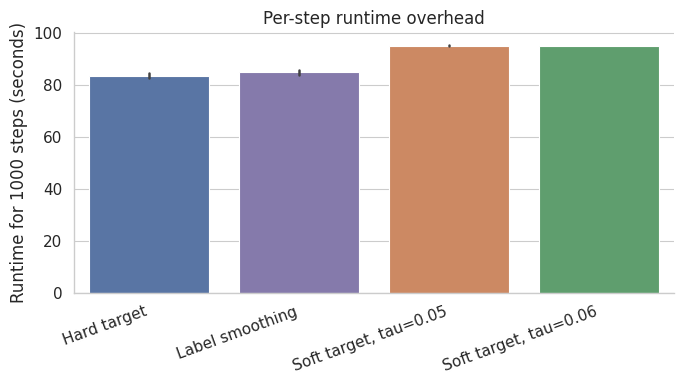

In [ ]:
# ============================================================
# Table 2. Runtime overhead at the final checkpoint
# ============================================================
runtime_summary = final_df.groupby("base_run").agg({
    "tokens_seen": ["mean", "std"],
    "elapsed_sec": ["mean", "std"],
    "test_perplexity": ["mean", "std"],
    "test_expected_embedding_distance": ["mean", "std"],
    "test_accuracy": ["mean", "std"],
})
runtime_summary = runtime_summary.rename(index=METHOD_LABELS)
display(runtime_summary)

runtime_plot = final_plot.copy()
plt.figure(figsize=(7, 4))
sns.barplot(
    data=runtime_plot,
    x="method",
    y="elapsed_sec",
    hue="method",
    order=[METHOD_LABELS[m] for m in METHOD_ORDER],
    palette=METHOD_PALETTE,
    errorbar="sd",
    legend=False,
)
plt.ylabel("Runtime for 1000 steps (seconds)")
plt.xlabel("")
plt.title("Per-step runtime overhead")
plt.xticks(rotation=20, ha="right")
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Threshold-based required data/runtime summary
# ============================================================
def threshold_summary(eval_history, metric, threshold, lower_is_better=True):
    rows = []

    for base_run, group in eval_history.groupby("base_run"):
        for seed, seed_group in group.groupby("seed"):
            seed_group = seed_group.sort_values("step")

            if lower_is_better:
                hit = seed_group[seed_group[metric] <= threshold]
            else:
                hit = seed_group[seed_group[metric] >= threshold]

            if len(hit) == 0:
                rows.append({
                    "base_run": base_run,
                    "method": METHOD_LABELS[base_run],
                    "seed": seed,
                    "metric": metric,
                    "threshold": threshold,
                    "tokens_required": np.nan,
                    "seconds_required": np.nan,
                    "hit": False,
                })
            else:
                first = hit.iloc[0]
                rows.append({
                    "base_run": base_run,
                    "method": METHOD_LABELS[base_run],
                    "seed": seed,
                    "metric": metric,
                    "threshold": threshold,
                    "tokens_required": first["tokens_seen"],
                    "seconds_required": first["elapsed_sec"],
                    "hit": True,
                })

    return pd.DataFrame(rows)

threshold_history = history_plot.dropna(subset=["perplexity", "expected_embedding_distance"]).copy()

required_df = pd.concat([
    threshold_summary(threshold_history, metric="perplexity", threshold=600, lower_is_better=True),
    threshold_summary(threshold_history, metric="expected_embedding_distance", threshold=0.42, lower_is_better=True),
], ignore_index=True)

required_summary = required_df.groupby(["metric", "method"]).agg({
    "hit": "mean",
    "tokens_required": ["mean", "std"],
    "seconds_required": ["mean", "std"],
})

display(required_df)
display(required_summary)


,base_run,method,seed,metric,threshold,tokens_required,seconds_required,hit
0,hard_baseline,Hard target,42,perplexity,600.00,508000,15.526785,True
1,hard_baseline,Hard target,43,perplexity,600.00,508000,14.172990,True
2,hard_baseline,Hard target,44,perplexity,600.00,508000,14.051064,True
3,label_smoothing_0.05,Label smoothing,42,perplexity,600.00,508000,15.226369,True
4,label_smoothing_0.05,Label smoothing,43,perplexity,600.00,508000,14.492715,True
5,label_smoothing_0.05,Label smoothing,44,perplexity,600.00,508000,14.423270,True
6,soft_tau_0.05,"Soft target, tau=0.05",42,perplexity,600.00,508000,16.842804,True
7,soft_tau_0.05,"Soft target, tau=0.05",43,perplexity,600.00,508000,16.798775,True
8,soft_tau_0.05,"Soft target, tau=0.05",44,perplexity,600.00,508000,16.715919,True
9,soft_tau_0.06,"Soft target, tau=0.06",42,perplexity,600.00,508000,16.697443,True


hit tokens_required       \
                                                  mean            mean  std   
metric                      method                                            
expected_embedding_distance Hard target            1.0        508000.0  0.0   
                            Label smoothing        1.0        508000.0  0.0   
                            Soft target, tau=0.05  1.0        508000.0  0.0   
                            Soft target, tau=0.06  1.0        508000.0  0.0   
perplexity                  Hard target            1.0        508000.0  0.0   
                            Label smoothing        1.0        508000.0  0.0   
                            Soft target, tau=0.05  1.0        508000.0  0.0   
                            Soft target, tau=0.06  1.0        508000.0  0.0   

                                                  seconds_required            
                                                              mean       std  
metric                      method                                            
expected_embedding_distance Hard target                  14.583613  0.819083  
                            Label smoothing              14.714118  0.444979  
                            Soft target, tau=0.05        16.785833  0.064425  
                            Soft target, tau=0.06        16.699166  0.005233  
perplexity                  Hard target                  14.583613  0.819083  
                            Label smoothing              14.714118  0.444979  
                            Soft target, tau=0.05        16.785833  0.064425  
                            Soft target, tau=0.06        16.699166  0.005233